# Dataset VALDO Task2 (MicroBleeds)

### Transformación dataset en formato nnUNetv2

In [ ]:
import os
import json
import shutil
from pathlib import Path

# -----------------------------
# CONFIGURACIÓN
# -----------------------------
# Ruta donde están los datos ORIGINALES (raw)
ORIGIN_DIR = "/media/PORT-DISK/Practicas/MicroBleeds/VALDO/Task2"

# Ruta base de nnUNet_raw (donde se creará la nueva carpeta)
NNUNET_RAW_BASE = "/media/PORT-DISK/Practicas/Microbleeds/nnUNet_raw_data"

# ID y Nombre del Dataset (Formato estricto nnUNetv2: DatasetXXX_Nombre)
DATASET_ID = 888 
DATASET_NAME = "VALDO_Task2"
FOLDER_NAME = f"Dataset{DATASET_ID}_{DATASET_NAME}"

# Rutas de destino finales
TARGET_DIR = os.path.join(NNUNET_RAW_BASE, FOLDER_NAME)
IMAGES_TR_DIR = os.path.join(TARGET_DIR, "imagesTr")
LABELS_TR_DIR = os.path.join(TARGET_DIR, "labelsTr")

# -----------------------------
# 1. PREPARACIÓN DE CARPETAS
# -----------------------------
if os.path.exists(TARGET_DIR):
    print(f"[Aviso] La carpeta destino ya existe: {TARGET_DIR}")
    print("Por seguridad, borra la carpeta destino manualmente si quieres regenerarla.")
    # exit() # Descomentar para evitar sobreescribir

os.makedirs(IMAGES_TR_DIR, exist_ok=True)
os.makedirs(LABELS_TR_DIR, exist_ok=True)

print(f"Generando dataset en: {TARGET_DIR}")

# -----------------------------
# 2. COPIA DE ARCHIVOS
# -----------------------------
# Buscamos las carpetas de sujetos (sub-XXX)
subject_folders = sorted([f for f in os.listdir(ORIGIN_DIR)
                          if f.startswith("sub") and os.path.isdir(os.path.join(ORIGIN_DIR, f))])

print(f"Se encontraron {len(subject_folders)} sujetos. Iniciando copia...")

for sub_folder in subject_folders:
    src_path = os.path.join(ORIGIN_DIR, sub_folder)
    
    # Definir rutas origen
    # Asegurarse de que coinciden
    src_t2s = os.path.join(src_path, f"{sub_folder}_space-T2S_desc-masked_T2S.nii.gz")
    src_t1  = os.path.join(src_path, f"{sub_folder}_space-T2S_desc-masked_T1.nii.gz")
    src_t2  = os.path.join(src_path, f"{sub_folder}_space-T2S_desc-masked_T2.nii.gz")
    src_lbl = os.path.join(src_path, f"{sub_folder}_space-T2S_CMB.nii.gz")

    # Comprobar que existen antes de copiar
    if not all(os.path.exists(p) for p in [src_t2s, src_t1, src_t2, src_lbl]):
        print(f"[ERROR] Faltan archivos en {sub_folder}. Saltando...")
        continue

    # Definir rutas destino (Renombrado nnUNetv2)
    # T2S -> 0000
    # T1  -> 0001
    # T2  -> 0002
    dst_t2s = os.path.join(IMAGES_TR_DIR, f"{sub_folder}_0000.nii.gz")
    dst_t1  = os.path.join(IMAGES_TR_DIR, f"{sub_folder}_0001.nii.gz")
    dst_t2  = os.path.join(IMAGES_TR_DIR, f"{sub_folder}_0002.nii.gz")
    dst_lbl = os.path.join(LABELS_TR_DIR, f"{sub_folder}.nii.gz")

    # Copiar (shutil.copy2 preserva metadatos)
    print(f"Procesando {sub_folder}...", end="\r")
    shutil.copy2(src_t2s, dst_t2s)
    shutil.copy2(src_t1, dst_t1)
    shutil.copy2(src_t2, dst_t2)
    shutil.copy2(src_lbl, dst_lbl)

print(f"\nCopia finalizada.")

# -----------------------------
# 3. GENERAR DATASET.JSON (Formato v2)
# -----------------------------
# CAMBIOS CLAVE v2:
# - "modality" -> "channel_names"
# - Las claves de channel_names deben ser strings ("0", "1")
# - "labels" debe ser mapa Nombre -> Int
# - Añadir "file_ending"

json_dict = {
    "name": DATASET_NAME,
    "description": "Microbleeds detection VALDO Task2 Multi-modal",
    "tensorImageSize": "3D",
    "reference": "VALDO Challenge",
    "licence": "",
    "release": "1.0",
    
    # AQUÍ ESTÁ EL CAMBIO CLAVE PARA v2:
    "channel_names": {
        "0": "T2S",
        "1": "T1",
        "2": "T2"
    },
    
    # Mapeo de etiquetas (Nombre -> Valor píxel)
    "labels": {
        "background": 0,
        "CMB": 1
    },
    
    "numTraining": len(subject_folders),
    "file_ending": ".nii.gz",
    
    # En v2, 'training' es opcional si la carpeta imagesTr está bien,
    # pero ponerlo ayuda a depurar.
    "training": [
        {
            "image": f"./imagesTr/{sub}.nii.gz",
            "label": f"./labelsTr/{sub}.nii.gz"
        }
        for sub in subject_folders
    ]
    # NOTA: En la sección 'training', NO se pone _0000 en el nombre del archivo.
    # nnUNet asume los sufijos de canal automáticamente.
}

json_path = os.path.join(TARGET_DIR, "dataset.json")
with open(json_path, 'w') as f:
    json.dump(json_dict, f, indent=4)

print(f"Dataset v2 creado en: {TARGET_DIR}")


Generando dataset en: /media/guest/PORT-DISK/Practicas/Microbleeds/nnUNet_raw_data/Dataset888_VALDO_Task2
Se encontraron 72 sujetos. Iniciando copia...
Procesando sub-327...
Copia finalizada.
Dataset v2 creado en: /media/guest/PORT-DISK/Practicas/Microbleeds/nnUNet_raw_data/Dataset888_VALDO_Task2


Guardado en:  /media/PORT-DISK/Practicas/Microbleeds/nnUNet_raw_data_VALDO/Dataset888_VALDO_Task2

### Análisis Resolución Dataset

In [ ]:
import os
import nibabel as nib
import numpy as np
import pandas as pd

# -----------------------------
# CONFIGURACIÓN
# -----------------------------
NNUNET_DIR = "/media/PORT-DISK/Practicas/MicroBleeds/nnUNet_raw_data_VALDO/Dataset888_VALDO_Task2"
imagesTr_dir = os.path.join(NNUNET_DIR, "imagesTr")
labelsTr_dir = os.path.join(NNUNET_DIR, "labelsTr")

# Definición de modalidades
MODALITIES = {
    "T2*": "_0000",
    "T1":  "_0001",
    "T2":  "_0002",
    "Mask": ""  # La máscara está en otra carpeta y no tiene sufijo numérico
}

def get_nifti_metadata(path, modality_name, sub_id):
    """Extrae metadatos del header sin cargar toda la imagen (más rápido)."""
    if not os.path.exists(path):
        return None

    try:
        nii = nib.load(path)
        header = nii.header
        
        # 1. Dimensiones (X, Y, Z)
        # Z suele ser el número de cortes en imágenes 3D médicas
        dims = nii.shape 
        
        # 2. Tamaño de Voxel (Spacing en mm)
        zooms = header.get_zooms()
        
        # 3. Orientación (RAS, LPS, etc.)
        # Convierte la matriz afín a códigos de letras (ej. ('R', 'A', 'S'))
        orientation = nib.aff2axcodes(nii.affine)
        
        # 4. Tipo de dato
        dtype = header.get_data_dtype()

        return {
            "Subject": sub_id,
            "Modality": modality_name,
            "Dim_X": dims[0],
            "Dim_Y": dims[1],
            "Dim_Z (Slices)": dims[2] if len(dims) > 2 else 1,
            "Voxel_X (mm)": round(zooms[0], 4),
            "Voxel_Y (mm)": round(zooms[1], 4),
            "Voxel_Z (mm)": round(zooms[2], 4),
            "Orientation": "".join(orientation),
            "DType": dtype
        }
    except Exception as e:
        print(f"Error leyendo {path}: {e}")
        return None

# -----------------------------
# EJECUCIÓN
# -----------------------------
# 1. Obtener lista de sujetos únicos
files = os.listdir(imagesTr_dir)
# Filtramos solo los que terminen en _0000.nii.gz para sacar el ID base
sub_ids = sorted([f.split("_")[0] for f in files if f.endswith("_0000.nii.gz")])

print(f"Detectados {len(sub_ids)} sujetos. Iniciando análisis...\n")

data_list = []

for sub_id in sub_ids:
    # Iterar por cada modalidad (T2*, T1, T2, Mask)
    for mod_name, suffix in MODALITIES.items():
        
        # Determinar ruta dependiendo si es imagen o label
        if mod_name == "Mask":
            filename = f"{sub_id}.nii.gz"
            path = os.path.join(labelsTr_dir, filename)
        else:
            filename = f"{sub_id}{suffix}.nii.gz"
            path = os.path.join(imagesTr_dir, filename)
            
        # Extraer datos
        meta = get_nifti_metadata(path, mod_name, sub_id)
        if meta:
            data_list.append(meta)
        else:
            # Registro de archivo faltante (opcional)
            print(f"Warning: Falta {mod_name} para sujeto {sub_id}")

# 2. Crear DataFrame de Pandas
df = pd.DataFrame(data_list)

      
# Agrupamos por modalidad para ver si todos tienen la misma resolución
# Esto es vital: nnU-Net prefiere que todos tengan mismo espaciado, 
# si no, hará resampling.

group_cols = ["Dim_X", "Dim_Y", "Dim_Z (Slices)", "Voxel_X (mm)", "Voxel_Y (mm)", "Voxel_Z (mm)"]

for mod in MODALITIES.keys():
    print(f"\n--- Análisis de Modalidad: {mod} ---")
    df_mod = df[df["Modality"] == mod]
    
    # Contamos cuántas combinaciones únicas de dimensiones/voxels existen
    unique_configs = df_mod[group_cols].value_counts()
    
    print(unique_configs)
    
    # Chequeo de Orientación
    orientations = df_mod["Orientation"].unique()
    if len(orientations) > 1:
        print(f"¡ALERTA! Orientaciones mixtas detectadas: {orientations}")
    else:
        print(f"Orientación consistente: {orientations[0]}")

# 3. Exportar a CSV (opcional, muy útil para abrir en Excel)
output_csv = "/media/PORT-DISK/Practicas/MicroBleeds/analisis_resolucion_dataset_VALDO_task2.csv"

df.to_csv(output_csv, index=False)
print(f"\nAnálisis completo guardado en: {output_csv}")

# 4. Mostrar primeras filas del análisis:
print("\nPrimeras filas del análisis:")
print(df.head(10))

Detectados 72 sujetos. Iniciando análisis...


--- Análisis de Modalidad: T2* ---
Dim_X  Dim_Y  Dim_Z (Slices)  Voxel_X (mm)  Voxel_Y (mm)  Voxel_Z (mm)
512    512    192             0.4883        0.4883        0.8000          34
              35              0.4492        0.4492        4.0000          11
256    256    39              1.0000        1.0000        3.0000           7
                                                          3.0001           4
                                                          4.0001           3
                                                          4.0000           2
              36              1.0000        1.0000        3.9996           1
                                                          4.0004           1
              39              1.0000        1.0000        2.9995           1
                                                          3.9994           1
                                                          3.0004           1


Guardado como: analisis_resolucion_dataset_VALDO_task2.csv

### Comprobación dimensiones imágenes vs máscaras

In [ ]:
import nibabel as nib
import numpy as np
import os
import glob

# ================= CONFIGURACIÓN =================
base_folder = "/media/PORT-DISK/Practicas/MicroBleeds/nnUNet_raw_data_VALDO/Dataset888_VALDO_Task2"

images_dir = os.path.join(base_folder, "imagesTr")
labels_dir = os.path.join(base_folder, "labelsTr")
# =================================================

def check_dataset_health(images_dir, labels_dir):
    # Obtener lista de máscaras (labels)
    mask_files = sorted(glob.glob(os.path.join(labels_dir, "*.nii.gz")))
    
    if not mask_files:
        print("No se encontraron archivos en labelsTr. Revisa la ruta.")
        return

    problematic_cases = []
    
    print(f"Analizando {len(mask_files)} casos...\n")

    for mask_path in mask_files:
        mask_name = os.path.basename(mask_path)
        case_id = mask_name.replace(".nii.gz", "")
        
        # Construir nombre esperado de la imagen (nnUNet añade _0000)
        image_name = f"{case_id}_0000.nii.gz"
        image_path = os.path.join(images_dir, image_name)
        
        # 1. Comprobar existencia del archivo de imagen
        if not os.path.exists(image_path):
            print(f"FALTA IMAGEN: Para la máscara {mask_name}, no existe {image_name}")
            problematic_cases.append((case_id, "Missing Image"))
            continue

        try:
            # Cargar archivos (sin leer todos los datos a memoria aún para ir rápido)
            mask_nii = nib.load(mask_path)
            img_nii = nib.load(image_path)
            
            # 2. Comprobar Dimensiones (Shape)
            if img_nii.shape != mask_nii.shape:
                print(f"SHAPE MISMATCH en {case_id}: Img {img_nii.shape} != Mask {mask_nii.shape}")
                problematic_cases.append((case_id, "Shape Mismatch"))
                continue
            
            # 3. Comprobar Affine (Geometría)
            if not np.allclose(img_nii.affine, mask_nii.affine, atol=1e-5):
                print(f"AFFINE MISMATCH en {case_id}")
                # Mostrar diferencia para depurar
                diff = np.max(np.abs(img_nii.affine - mask_nii.affine))
                print(f"   Dif. máxima: {diff:.6f}")
                problematic_cases.append((case_id, "Affine Mismatch"))
                continue
                
            # 4. Comprobar corrupción de datos (NaNs)
            # Solo leemos los datos si pasa las pruebas anteriores
            if np.isnan(np.sum(mask_nii.get_fdata())):
                print(f"CORRUPCIÓN (NaNs) en la máscara: {case_id}")
                problematic_cases.append((case_id, "NaNs in Mask"))
                continue

        except Exception as e:
            print(f"ERROR LECTURA en {case_id}: {str(e)}")
            problematic_cases.append((case_id, "File Read Error"))

    # --- RESUMEN FINAL ---
    print("\n" + "="*30)
    print("RESUMEN DEL DIAGNÓSTICO")
    print("="*30)
    
    if len(problematic_cases) == 0:
        print("TODO PERFECTO. Los 72 casos tienen geometría coincidente.")
        print("Si nnUNet sigue fallando, revisa tu dataset.json o memoria RAM.")
    else:
        print(f"Se encontraron {len(problematic_cases)} casos problemáticos:\n")
        for case, reason in problematic_cases:
            print(f"  • {case}: {reason}")

# Ejecutar
check_dataset_health(images_dir, labels_dir)

Analizando 72 casos...

AFFINE MISMATCH en sub-103
   Dif. máxima: 0.000011
AFFINE MISMATCH en sub-107
   Dif. máxima: 0.000152
AFFINE MISMATCH en sub-109
   Dif. máxima: 0.000012
AFFINE MISMATCH en sub-111
   Dif. máxima: 0.000012

RESUMEN DEL DIAGNÓSTICO
Se encontraron 4 casos problemáticos:

  • sub-103: Affine Mismatch
  • sub-107: Affine Mismatch
  • sub-109: Affine Mismatch
  • sub-111: Affine Mismatch


Conclusión: diferencias mínimas entre imagen y máscara en algunos casos, no es problemático

### Visualización imágenes con CMBs marcadas

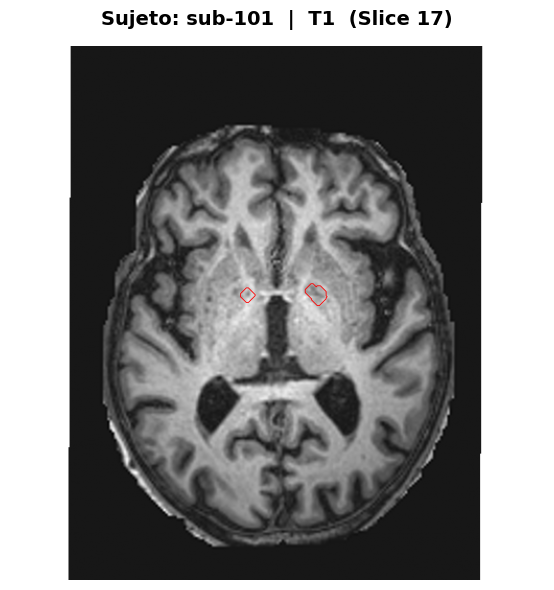

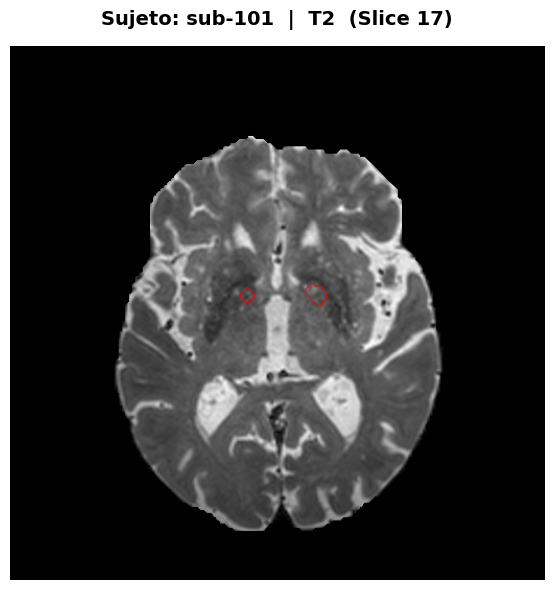

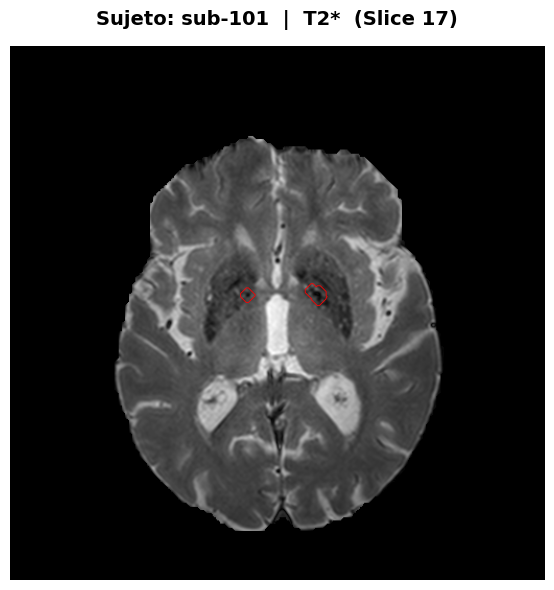

In [ ]:
import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage

# -----------------------------
# CONFIGURACIÓN
# -----------------------------
NNUNET_DIR = "/media/PORT-DISK/Practicas/MicroBleeds/nnUNet_raw_data_VALDO/Dataset888_VALDO_Task2"
imagesTr_dir = os.path.join(NNUNET_DIR, "imagesTr")
labelsTr_dir = os.path.join(NNUNET_DIR, "labelsTr")

SUFFIX_T2S = "_0000"
SUFFIX_T1  = "_0001"
SUFFIX_T2  = "_0002"

# --- AJUSTES VISUALES ---
LINE_WIDTH = 0.6      # Grosor del contorno (muy fino)
EXPANSION_PX = 5      # Píxeles de separación (radio de la "diana")
TITULO_PAD = 15       # Separación del título hacia arriba

# -----------------------------
# Funciones
# -----------------------------
def load_nifti(path):
    if not os.path.exists(path): return None
    return nib.load(path).get_fdata()

def resize_to_match(img, target_shape, order=3):
    """Iguala resoluciones para que T1 no se vea pequeño."""
    if img.shape == target_shape: return img
    factors = (target_shape[0]/img.shape[0], target_shape[1]/img.shape[1])
    return scipy.ndimage.zoom(img, factors, order=order)

def plot_individual_figures(t1, t2, t2s, mask, sub_id, slice_idx):
    
    # 1. Preparar datos (Transponer .T y obtener corte)
    s_t1 = t1[:, :, slice_idx].T
    s_t2 = t2[:, :, slice_idx].T
    s_t2s = t2s[:, :, slice_idx].T
    s_mask = mask[:, :, slice_idx].T

    # 2. Igualar tamaños usando T2* como base
    target_shape = s_t2s.shape
    s_t1 = resize_to_match(s_t1, target_shape, order=3)
    s_t2 = resize_to_match(s_t2, target_shape, order=3)
    s_mask = resize_to_match(s_mask, target_shape, order=0)

    # 3. Crear máscara expandida (Diana)
    # Se dilata la máscara para que el círculo rojo rodee la lesión sin tocarla
    mask_expanded = scipy.ndimage.binary_dilation(s_mask, iterations=EXPANSION_PX)

    # Lista de configuraciones para iterar
    # (Nombre Modalidad, Datos Imagen)
    plots = [
        ("T1", s_t1),
        ("T2", s_t2),
        ("T2*", s_t2s)
    ]

    # 4. Generar UNA figura distinta por cada modalidad
    for modality_name, img_data in plots:
        plt.figure(figsize=(6, 6)) # Cuadrado perfecto
        
        # Imagen de fondo
        plt.imshow(img_data, cmap="gray", origin="lower")
        
        # Contorno Rojo
        plt.contour(mask_expanded, levels=[0.5], colors='red', linewidths=LINE_WIDTH)
        
        # Título arriba y separado
        full_title = f"Sujeto: {sub_id}  |  {modality_name}  (Slice {slice_idx})"
        plt.title(full_title, fontsize=14, fontweight='bold', pad=TITULO_PAD)
        
        plt.axis("off")
        plt.tight_layout()
        plt.show() # Muestra y cierra la figura actual para empezar la siguiente

# -----------------------------
# Ejecución
# -----------------------------
files_t2s = sorted([f for f in os.listdir(imagesTr_dir) if f.endswith(f"{SUFFIX_T2S}.nii.gz")])
sub_ids = [f.split("_")[0] for f in files_t2s]

if sub_ids:
    # ELIGE AQUÍ EL SUJETO (0, 1, 2...)
    sub_id = sub_ids[0]
    
    p_t2s = os.path.join(imagesTr_dir, f"{sub_id}{SUFFIX_T2S}.nii.gz")
    p_t1  = os.path.join(imagesTr_dir, f"{sub_id}{SUFFIX_T1}.nii.gz")
    p_t2  = os.path.join(imagesTr_dir, f"{sub_id}{SUFFIX_T2}.nii.gz")
    p_lbl = os.path.join(labelsTr_dir, f"{sub_id}.nii.gz")

    d_t2s = load_nifti(p_t2s)
    d_t1  = load_nifti(p_t1)
    d_t2  = load_nifti(p_t2)
    d_lbl = load_nifti(p_lbl)

    if d_t2s is not None and d_t1 is not None and d_t2 is not None:
        if np.sum(d_lbl) > 0:
            # Buscar corte con más lesión
            slice_idx = np.argmax(np.sum(d_lbl, axis=(0, 1)))
            plot_individual_figures(d_t1, d_t2, d_t2s, d_lbl, sub_id, slice_idx)
        else:
            print(f"El sujeto {sub_id} no tiene lesiones marcadas en la máscara.")

### Análisis CMBs conteo y volumen (global y por cohortes)

In [ ]:
import os
import csv
import numpy as np
import nibabel as nib
from scipy.ndimage import label
import pandas as pd
import matplotlib.pyplot as plt

# CONFIGURACIÓN

NNUNET_DIR = "media/PORT-DISK/Practicas/MicroBleeds/nnUNet_raw_data_VALDO/TaskVALDO"
LABELS_DIR = os.path.join(NNUNET_DIR, "labelsTr")

# Nombre actualizado para el análisis
OUTPUT_CSV = "/media/PORT-DISK/Practicas/MicroBleeds/nnUNet_raw_data_VALDO/VALDO_analisis_por_cohortes.csv"

# FUNCIONES AUXILIARES

def get_cohort(subject_id):
    """
    Determina la cohorte basándose en el ID del paciente.
    sub-1xx -> SABRE (UK)
    sub-2xx -> RSS (Rotterdam)
    sub-3xx -> ALFA (Barcelona)
    """
    try:
        parts = subject_id.split('-')
        if len(parts) > 1:
            num_str = parts[1]
            if num_str.startswith('1'):
                return "SABRE"
            elif num_str.startswith('2'):
                return "RSS"
            elif num_str.startswith('3'):
                return "ALFA"
    except Exception:
        pass
    return "Unknown"

def analyze_mask(label_path):
    """
    Analiza la máscara y devuelve el número de lesiones y sus volúmenes en cm³.
    """
    nii = nib.load(label_path)
    mask = nii.get_fdata().astype(np.uint8)

    # Tamaño de voxel en mm (dx, dy, dz)
    voxel_sizes = nii.header.get_zooms()[:3]
    # Volumen de un solo vóxel en mm³
    one_voxel_vol_mm3 = voxel_sizes[0] * voxel_sizes[1] * voxel_sizes[2]

    # Connected components (etiquetar cada lesión individualmente)
    labeled, num = label(mask)

    lesion_volumes_vox = []
    lesion_volumes_cm3 = []

    for lesion_idx in range(1, num + 1):
        # Conteo de vóxeles para esta lesión
        voxel_count = int(np.sum(labeled == lesion_idx))
        lesion_volumes_vox.append(voxel_count)

        # Cálculo de volumen:
        # 1. Volumen en mm³ = vóxeles * volumen_voxel
        vol_mm3 = voxel_count * one_voxel_vol_mm3
        
        # 2. Conversión a cm³ (1 cm³ = 1000 mm³)
        vol_cm3 = round(vol_mm3 / 1000.0, 6) # Usamos 6 decimales por ser lesiones muy pequeñas
        
        lesion_volumes_cm3.append(vol_cm3)

    return num, lesion_volumes_vox, lesion_volumes_cm3


# PROCESAMIENTO DE DATOS Y GENERACIÓN CSV

rows = []
label_files = sorted([f for f in os.listdir(LABELS_DIR) if f.endswith(".nii.gz")])

print(f"Procesando {len(label_files)} sujetos...")

for f in label_files:
    subject = f.replace(".nii.gz", "")
    path = os.path.join(LABELS_DIR, f)
    
    # Identificar cohorte
    cohort = get_cohort(subject)

    # Analizar máscara
    num_lesions, lesion_volumes_vox, lesion_volumes_cm3 = analyze_mask(path)

    if num_lesions == 0:
        # Paciente sin lesiones → fila única con ceros
        rows.append([subject, cohort, 0, 0, 0.0])
    else:
        # Una fila por cada lesión encontrada
        for vvox, vcm3 in zip(lesion_volumes_vox, lesion_volumes_cm3):
            rows.append([subject, cohort, num_lesions, vvox, vcm3])

# Guardar CSV
with open(OUTPUT_CSV, "w", newline="") as csvfile:
    writer = csv.writer(csvfile)
    # Cabecera clara
    writer.writerow(["subject", "cohort", "num_lesions_patient", "lesion_vol_voxels", "volume_cm3"])
    writer.writerows(rows)

print("Análisis completado. CSV guardado en:", OUTPUT_CSV)

Procesando 72 sujetos...
Análisis completado. CSV guardado en: C:\Users\marta\Desktop\microbleeds\VALDO_analisis_por_cohortes.csv


Guardado en: "/media/PORT-DISK/Practicas/MicroBleeds/nnUNet_raw_data_VALDO"

#### ANÁLISIS GLOBAL:

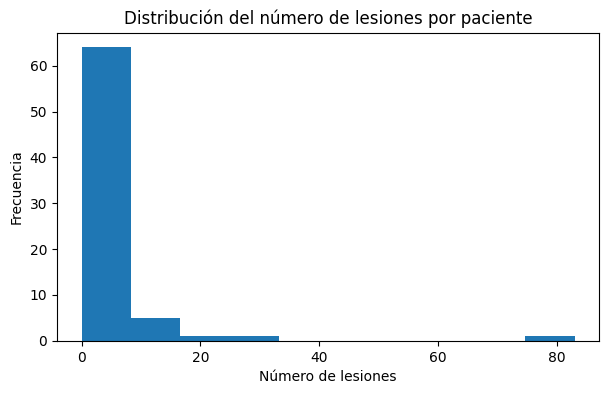

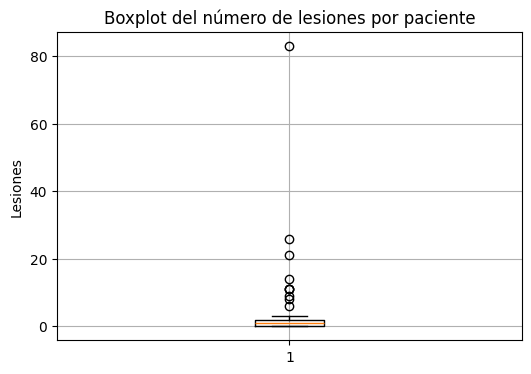

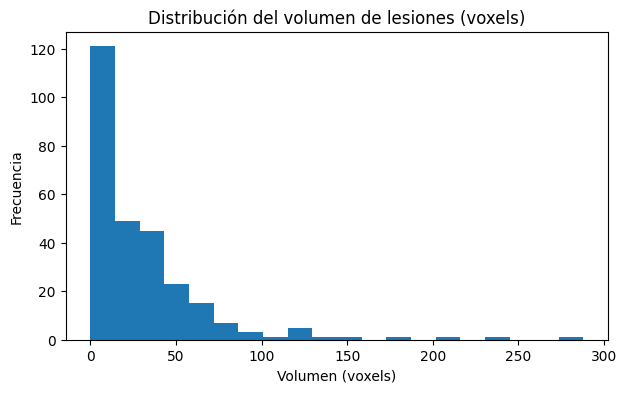

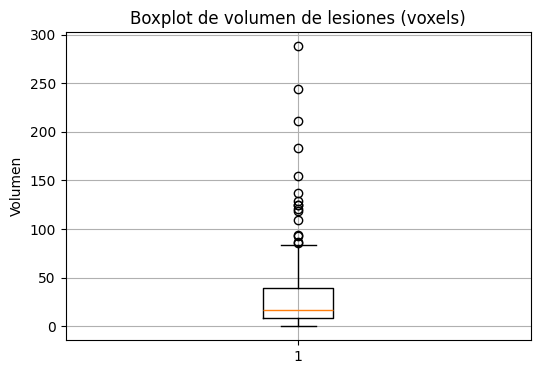

In [ ]:
# CARGAR DATOS PARA GRÁFICAS

import pandas as pd
df = pd.read_csv("/media/PORT-DISK/Practicas/MicroBleeds/nnUNet_raw_data_VALDO/VALDO_analisis_por_cohortes.csv")

# GRÁFICAS — DISTRIBUCIONES

# ---------- Histograma número de lesiones ----------
plt.figure(figsize=(7,4))
df.groupby("subject").first()["num_lesions"].hist(bins=10)
plt.title("Distribución del número de lesiones por paciente")
plt.xlabel("Número de lesiones")
plt.ylabel("Frecuencia")
plt.grid()
plt.show()

# ---------- Boxplot número de lesiones ----------
plt.figure(figsize=(6,4))
plt.boxplot(df.groupby("subject").first()["num_lesions"])
plt.title("Boxplot del número de lesiones por paciente")
plt.ylabel("Lesiones")
plt.grid()
plt.show()

# ---------- Histograma volumen de lesiones ----------
plt.figure(figsize=(7,4))
df["volume_voxels"].hist(bins=20)
plt.title("Distribución del volumen de lesiones (voxels)")
plt.xlabel("Volumen (voxels)")
plt.ylabel("Frecuencia")
plt.grid()
plt.show()

# ---------- Boxplot volumen ----------
plt.figure(figsize=(6,4))
plt.boxplot(df["volume_voxels"])
plt.title("Boxplot de volumen de lesiones (voxels)")
plt.ylabel("Volumen")
plt.grid()
plt.show()

#### ANÁLISIS POR COHORTE:


--- Vista previa de los datos ---
   subject cohort  num_lesions_patient  lesion_vol_voxels  volume_cm3
0  sub-101  SABRE                   14                 16    0.012915
1  sub-101  SABRE                   14                  9    0.007265
2  sub-101  SABRE                   14                 22    0.017758
3  sub-101  SABRE                   14                 14    0.011301
4  sub-101  SABRE                   14                 81    0.065382


<Figure size 1000x600 with 0 Axes>

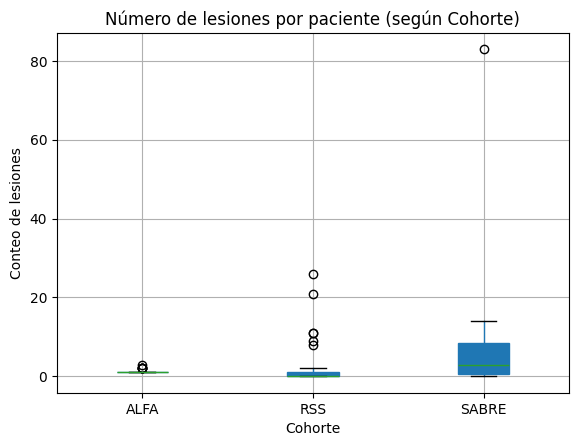

<Figure size 1000x600 with 0 Axes>

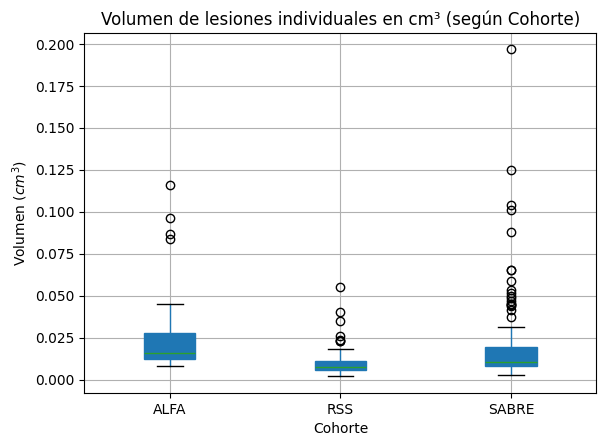


=== RESUMEN ESTADÍSTICO ===

>> Conteo de lesiones por paciente (Media +/- Std):
             mean        std  max  count
cohort                                  
ALFA     1.259259   0.525693    3     27
RSS      2.823529   6.142108   26     34
SABRE   11.181818  24.268573   83     11

>> Volumen de lesiones en cm³ (Media +/- Std):
            mean    median       std       max
cohort                                        
ALFA    0.027499  0.016000  0.027149  0.115987
RSS     0.009799  0.007629  0.007836  0.054932
SABRE   0.020639  0.010493  0.026332  0.196954


In [ ]:
# VISUALIZACIÓN POR COHORTES

# Cargar el CSV recién creado
df = pd.read_csv("/media/PORT-DISK/Practicas/MicroBleeds/nnUNet_raw_data_VALDO/VALDO_analisis_por_cohortes.csv")

print("\n--- Vista previa de los datos ---")
print(df.head())

# --- GRÁFICO 1: Número de lesiones por paciente (Comparativa por Cohorte) ---
# Agrupamos por paciente (tomamos el primer valor ya que 'num_lesions_patient' se repite por fila)
df_patients = df.groupby(["subject", "cohort"])["num_lesions_patient"].first().reset_index()

plt.figure(figsize=(10, 6))
df_patients.boxplot(column="num_lesions_patient", by="cohort", grid=True, patch_artist=True)
plt.title("Número de lesiones por paciente (según Cohorte)")
plt.suptitle("") # Limpiar título automático
plt.ylabel("Conteo de lesiones")
plt.xlabel("Cohorte")
plt.show()

# --- GRÁFICO 2: Volumen de lesiones individuales en cm³ (Comparativa por Cohorte) ---
# Filtramos para no graficar el volumen "0" de los pacientes sanos
df_lesions = df[df["volume_cm3"] > 0]

plt.figure(figsize=(10, 6))
df_lesions.boxplot(column="volume_cm3", by="cohort", grid=True, patch_artist=True)
plt.title("Volumen de lesiones individuales en cm³ (según Cohorte)")
plt.suptitle("")
plt.ylabel("Volumen ($cm^3$)")
plt.xlabel("Cohorte")
plt.show()

# --- ESTADÍSTICAS EN TEXTO ---
print("\n=== RESUMEN ESTADÍSTICO ===")
print("\n>> Conteo de lesiones por paciente (Media +/- Std):")
print(df_patients.groupby("cohort")["num_lesions_patient"].agg(['mean', 'std', 'max', 'count']))

print("\n>> Volumen de lesiones en cm³ (Media +/- Std):")
print(df_lesions.groupby("cohort")["volume_cm3"].agg(['mean', 'median', 'std', 'max']))

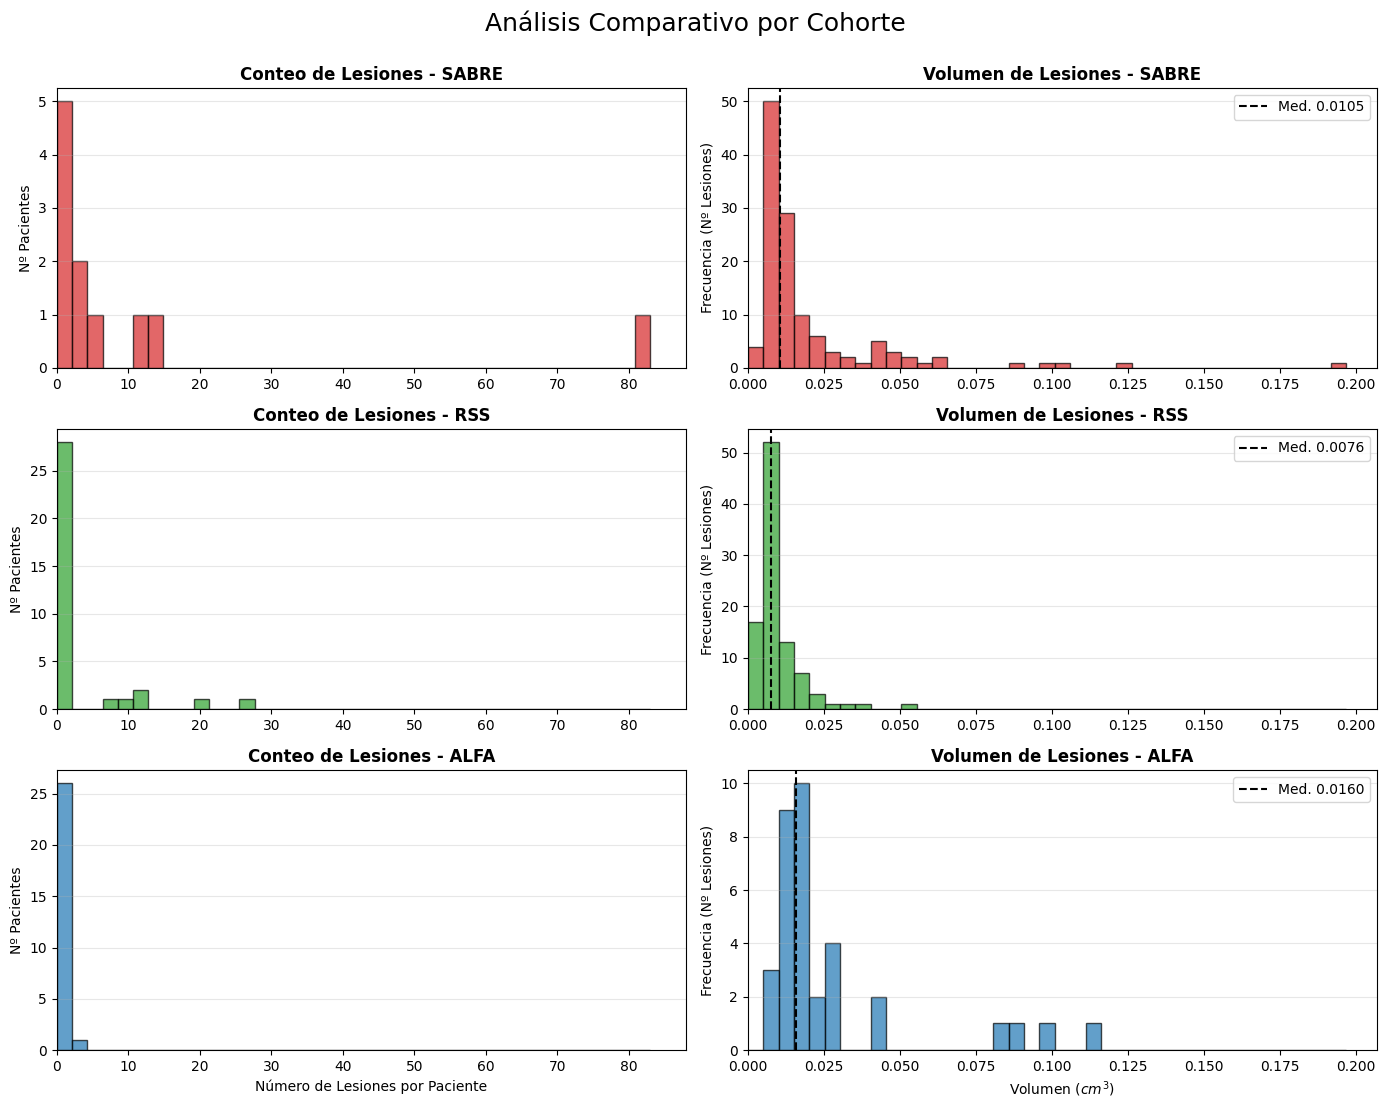

In [ ]:
# CARGA DE DATOS

OUTPUT_CSV = "/media/PORT-DISK/Practicas/MicroBleeds/nnUNet_raw_data_VALDO/VALDO_analisis_por_cohortes.csv"
df = pd.read_csv(OUTPUT_CSV)

# Definir el orden específico de las filas
cohorts_order = ["SABRE", "RSS", "ALFA"]
colors = {'SABRE': '#d62728', 'RSS': '#2ca02c', 'ALFA': '#1f77b4'} # Rojo, Verde, Azul

# Preparar datos agregados
df_patients = df.groupby(["subject", "cohort"], observed=False)["num_lesions_patient"].first().reset_index()
df_lesions = df[df["volume_cm3"] > 0]

# CÁLCULO DE LÍMITES GLOBALES (Para unificar ejes)

# Buscamos el valor máximo de TODO el dataset para que todos los gráficos usen la misma escala
max_num_lesiones = df_patients["num_lesions_patient"].max()
max_volumen = df_lesions["volume_cm3"].max()

# Definimos los límites del Eje X con un pequeño margen
xlim_lesiones = (0, max_num_lesiones + 5)
xlim_volumen = (0, max_volumen + 0.01)

# GENERACIÓN DE GRÁFICOS (GRID 3x2)

# Creamos una figura con 3 filas y 2 columnas
fig, axes = plt.subplots(3, 2, figsize=(14, 12)) # Alto ajustado para 3 filas
fig.suptitle('Análisis Comparativo por Cohorte', fontsize=18, y=0.95)

for i, cohort in enumerate(cohorts_order):
    # Seleccionar ejes de la fila actual
    ax_izq = axes[i, 0] # Histograma de Número (Izquierda)
    ax_der = axes[i, 1] # Histograma de Volumen (Derecha)
    
    # --- A. GRÁFICO IZQUIERDO: NÚMERO DE LESIONES ---
    data_pat = df_patients[df_patients["cohort"] == cohort]
    
    if len(data_pat) > 0:
        # Usamos bins consistentes para todo el rango
        bins_num = np.linspace(0, max_num_lesiones, 40) 
        ax_izq.hist(data_pat["num_lesions_patient"], bins=bins_num, color=colors[cohort], alpha=0.7, edgecolor='black')
    
    # Configuración Ejes Izquierda
    ax_izq.set_title(f"Conteo de Lesiones - {cohort}", fontsize=12, fontweight='bold')
    ax_izq.set_ylabel("Nº Pacientes")
    ax_izq.set_xlim(xlim_lesiones) # <--- AQUÍ UNIFICAMOS LA ESCALA
    ax_izq.grid(axis='y', alpha=0.3)
    
    # Solo ponemos etiqueta X en la última fila para no ensuciar
    if i == 2: ax_izq.set_xlabel("Número de Lesiones por Paciente")

    # --- B. GRÁFICO DERECHO: VOLUMEN ---
    data_vol = df_lesions[df_lesions["cohort"] == cohort]
    
    if len(data_vol) > 0:
        # Usamos bins consistentes
        bins_vol = np.linspace(0, max_volumen, 40)
        ax_der.hist(data_vol["volume_cm3"], bins=bins_vol, color=colors[cohort], alpha=0.7, edgecolor='black')
        
        # Mediana
        mediana = data_vol["volume_cm3"].median()
        ax_der.axvline(mediana, color='black', linestyle='--', linewidth=1.5, label=f'Med. {mediana:.4f}')
        ax_der.legend(loc='upper right')

    # Configuración Ejes Derecha
    ax_der.set_title(f"Volumen de Lesiones - {cohort}", fontsize=12, fontweight='bold')
    ax_der.set_ylabel("Frecuencia (Nº Lesiones)")
    ax_der.set_xlim(xlim_volumen) # <--- AQUÍ UNIFICAMOS LA ESCALA
    ax_der.grid(axis='y', alpha=0.3)
    
    if i == 2: ax_der.set_xlabel("Volumen ($cm^3$)")

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajuste para que no se corte el título grande
plt.show()